# Deep TIQ - Segmentation of human lung epithelium PCW14
---


## I - Introduction

This notebook shows how to train **deep neural networks** to perform **semantic segmentation** of lung epithelium in fluorescence images acquired on fixed wholemounts of human embryonic lung. Epithelium is segmented on the basis of the fluorescence signal of the cell membranes immunostained against E-Cadherin.

**Training**

Deep TIQ offers a large variety of ready-to-use **convolutional neural networks** for image segmentation and analysis:

<figure>
<center>
<img src="https://drive.google.com/uc?id=1iQROM-ko3lOCTF191qWB6nrFdp3OpWaU" width="500">
</figure>

In this notebook, we provide a variety of training examples for each kind of **network architecture** provided with Deep TIQ, each example demonstrating the impact on training performances of some **hyperparameters** such as the **loss function**, **image augmentation**, **encoder architecture** or **fine-tuning**.

**Data Set**

The data set consists in 2D **fluorescence images** of **embryonic human lung** immunostained against **E-Cadherin**. Images are 2D slices of **1664 x 1664 microns** with a resolution of **1.63 x 1.63 μm/pixel**. In total, there are **110 images and ground truth binary masks**. To train the network, the image and mask pairs are tilled into **random 256x256 pixels image patches** and split into 3 batches: **training, validation and test** with a default **70:15:15 ratio**.

**Data Management**

Images are organized as follows on the drive:

```
    My Drive/Deep_TIQ/Human_Lung/Data_PCW14/
                                     |-- Training/
                                     |    |-- Input/
                                     |    |      image_xxx.tif
                                     |    |       ...
                                     |    |-- Output/
                                     |    |      mask_xxx.tif
                                     |    |       ...
                                     |-- Prediction/
                                     |    |-- Input/
                                     |    |      image_yyy.tif
                                     |    |       ...
                                     |    |-- Output/
                                     |    |      mask_yyy.tif
                                     |    |       ...
                                     |-- Evaluation/
                                     |    |
                                     |    |       ...
```


## II - Computing environment

### Hardware
Provide informations on the hardware used by Colab during the session.

GPU and CUDA version

In [ ]:
print('# GPU Name:')
!nvidia-smi -L

print('# CUDA Version:')
!nvcc --version

# GPU Name:
/bin/bash: line 1: nvidia-smi: command not found
# CUDA Version:
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


CPU

In [ ]:
# CPU
!lscpu |grep 'Model name'

# No.of cores per socket
!lscpu | grep 'Core(s) per socket:'

# No.of threads each CPU core is having
!lscpu | grep 'Thread(s) per core'

# Actual operation frequency
!lscpu | grep "MHz"

Model name:                         AMD EPYC 7B12
Core(s) per socket:                 4
Thread(s) per core:                 2


RAM and Hard Disk

In [ ]:
# RAM available
!free -h --si | awk  '/Mem:/{print $2}'



52G


In [ ]:
# Hard disk space available
!df -h / | awk '{print $4}'

Avail
167G


 ### Reset variables

Delete local variables avoiding to reload the notebook when running it again.

In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


### Import Tensorflow & Keras

Import Tensorflow and Keras which are respectively a high level python library and API for deep learning.


In [ ]:
# Install Tensorflow 2.8.2
!pip install tensorflow==2.8.2 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 103.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 43.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 53.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-gbq 0.19.2 requires google-auth-oauthlib>=0.7.0, but you have google-auth-oauthlib 0.4.6 which is incompatible.
tensorflow-datasets 4.9.4 requires protobuf>=3.20, but you h

In [ ]:
# Restart the runtime (needed as we install a custom Tensorflow version)
exit()
print('Runtime restarted.')

Runtime restarted.


In [ ]:
# Import Tensorflow
import tensorflow as tf
print(tf.__version__)

2.8.2


In [ ]:
# Install Keras 2.8.0
!pip install keras==2.8.0 --quiet

In [ ]:
# Import Keras
import keras
print(keras.__version__)

2.8.0


### Install third party libraries

In [ ]:
# Intall segmentation models
!pip install -U segmentation-models --quiet

# Select environment using tf.keras
%env SM_FRAMEWORK=tf.keras

# Import segmentation models
import segmentation_models as sm

print('Segmentation models has been sucessfully imported.')

env: SM_FRAMEWORK=tf.keras
Segmentation models has been sucessfully imported.


In [ ]:
# Install simple itk
!pip install simpleitk --quiet



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 26.6 MB/s eta 0:00:00


In [ ]:
# Install patchify
!pip install patchify --quiet


In [ ]:
# Install Latextable
!pip install -q latextable --quiet

print('Latextable has been sucessfully imported.')

Latextable has been sucessfully imported.


In [ ]:
# Installs Colorcet
!pip install colorcet --quiet

print('Colorcet has been sucessfully imported.')

Colorcet has been sucessfully imported.


### Import standard libraries

In [ ]:
# Python modules
import os, sys

import warnings
warnings.filterwarnings('ignore')
#warnings.filterwarnings(action='once')

# Numpy
import numpy as np

# Pandas
import pandas as pd

#Scipy
import scipy as sp

# Scikit-image
from skimage import io, color, img_as_float
from skimage.util import img_as_ubyte

# Matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
#Comment (and uncomment line below) if you don't want to use the inline interactive backend with matplotlib figures
%matplotlib inline
#mpl.use('agg')

# Seaborn
import seaborn as sns

# Albumentations
import albumentations as A

# Tensorflow and Keras functions
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import save_model, load_model, Model
from tensorflow.keras.layers import Input, Conv2D

print('Standard Python libraries and functions have been sucessfully imported.')

Standard Python libraries and functions have been sucessfully imported.


### Mount Google Drive

Google Drive is imported as a local directory so we can access image files stored in dedicated folders under `My Drive`.

In [ ]:
# Load drive as local folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


### Import Deep TIQ

Import Deep TIQ models and utility functions for image segmentation.

In [ ]:
# Path to driver folder where Deep TIQ is located
sys.path.append('/content/drive/My Drive/Deep_TIQ/Code/Segmentation/')

# Import Deep TIQ
import Deep_TIQ_Segmentation

print('Deep TIQ has been sucesfully imported.')

Deep TIQ has been sucesfully imported.


In [ ]:
# To run in case of changes in Deep_TIQ_Segmentation
import importlib
importlib.reload(Deep_TIQ_Segmentation)

<module 'Deep_TIQ_Segmentation' from '/content/drive/My Drive/Deep_TIQ/Code/Segmentation/Deep_TIQ_Segmentation.py'>

**Note: If the training, validation and test data sets are already prepared & saved you can skip sections IV & V and go to section VI for training.**

## III - Import original images & masks

Import the images and ground truth binary masks which will be used for the training of the deep neural network.

### Load images & masks

In [ ]:
from Deep_TIQ_Segmentation import load_images

# Define path to training images and ground truth binary masks
train_path ='/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/'

# Import training images and masks
train_images = load_images(train_path,'Input/','.tif')
train_masks = load_images(train_path,'Output/','.tif')

### Example images & masks

Display a random example image and its ground truth binary mask from the input training data set.

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(train_images)))

# Show an example training image / mask pair
images = [train_images[s_im], train_masks[s_im]]

names = ['Image', 'Binary mask']

cmaps = ['gray', 'gray']

example_images_plot(images, names, cmaps)

## IV - Weight maps

Generate for eack ground truth binary mask a **pixel-wise weight map allocating  different weights to pixels in the image** to correct for:
*  class imbalance between foreground and background pixels;
*  under-segmentation of touching foreground instances.

### Compute weight maps

In [ ]:
from Deep_TIQ_Segmentation import compute_weight_maps

# Define path to save weight maps
train_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/'

# Set weight and kernel size parameters for computing weight maps
l_0 = 50
sigma_bal = 10
sigma_sep = 6

# Compute and save pixel-wise weight maps as 32-bits tif image files
weight_maps = compute_weight_maps(train_path, 'Output/', '.tif', l_0, sigma_bal, sigma_sep, train_path, 'Weight_Maps/')

### Load weight maps

In [ ]:
from Deep_TIQ_Segmentation import load_weight_maps

# Define path to pixel-wise weight maps
train_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/'

# Load pixel-wise weight maps
weight_maps = load_weight_maps(train_path,'Weight_Maps/','.tif')

### Example weight maps

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(train_images)))

# Select what to plot
images = [train_images[s_im], train_masks[s_im], weight_maps[s_im]]

names = ['Image', 'Binary mask','Weight map']

cmaps = ['gray', 'gray', 'viridis']

In [ ]:
# Plot example training image / binary mask / weight map
example_images_plot(images, names, cmaps, contour=True, contour_image=train_masks[s_im], contour_target='Weight map', color_bar=True, color_bar_target='Weight map', save_plot=True, path=output_path, file_name='Training_')

## V - Data set preparation

### Generate training patches

Generate random  patches of fixed size by cropping input images, output binary masks and weight maps accordingly.

In [ ]:
# Create for each image/mask/weight map a certain number of patches of a given size
from Deep_TIQ_Segmentation import random_patches

N_patch = 12 # Number of patches per training image

patch_size = [256,256] # Patch size (x,y) in pixel

bck_th = 0.025 # Mean pixel intensity threshold for discarding patches containing mostly background.

#Compute training patches
train_input_patches, train_output_patches, train_weight_patches = random_patches(train_images, train_masks, weight_maps, N_patch, patch_size, bck_th)

### Example training patches

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(train_input_patches)))

# Select what to plot
images = [train_input_patches[s_im], train_output_patches[s_im], train_weight_patches[s_im]]

names = ['Image patch', 'Binary mask patch','Weight map patch']

cmaps = ['gray', 'gray', 'viridis']

In [ ]:
# Plot example training patch / binary mask / weight map
example_images_plot(images, names, cmaps, contour=True, contour_image=train_output_patches[s_im], contour_target='Weight map patch', color_bar=False, color_bar_target='Weight map patch', save_plot=True, path=output_path, file_name='Training_Patch_')

### Data set splitting
In order to train and evaluate the performance of the model, the initial data set is split into three sub-sets:

* **Training data set**: data set on which the model is trained. Usually 70-80% of the initial data set.
*  **Validation data set**: data set used to assess the progress of the training on the fly. Usually 10-15% of the initial data set.
*  **Validation data set**: data set containing unseen images during training and used to evaluate the performance of the trained model. Usually 10-15% of the initial data set.


In [ ]:
from Deep_TIQ_Segmentation import data_set_split

# Output path for saving the data sets
train_output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/'
test_output_path =  '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/'

# Data set spliting parameters
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15
Seed = 1

# Split data set
X_train, Y_train, W_train, X_test, Y_test, W_test, X_val, Y_val, W_val = data_set_split (train_input_patches, train_output_patches, train_weight_patches, train_ratio, val_ratio, test_ratio, seed=Seed, shuffle=True, save_data=True, train_path=train_output_path, test_path=test_output_path, train_folder='Training_Data/', val_folder='Validation_Data/', test_folder='Test_Data/')

## VI - Training

Train Deep TIQ predefined neural network models using images of the training data set.


### Training image set loading

Load images of the training data set for model(s) training.

#### Load training image set

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to training data set
training_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Training_Data/'

# Load training patches
training_input_patches =  load_patches(training_path,'Training_Images/',".tif", w_map=False)
training_output_patches =  load_patches(training_path,'Training_Masks/',".tif", w_map=False)
training_weight_patches =  load_patches(training_path,'Training_Weights/',".tif", w_map=True)

**Note: For some CNN architecture (e.g. PSPNet), you need to generate a resized training image set. If needed, run this cell instead:**

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to training data set
training_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data_PCW14/Training/Training_Data/'

# New patch shape
p_shape = (240,240)

# Load training patches
training_input_patches =  load_patches(training_path,'Training_Images/',".tif", w_map=False, re_size=True, new_shape= p_shape)
training_output_patches =  load_patches(training_path,'Training_Masks/',".tif", w_map=False, re_size=True, new_shape= p_shape)
training_weight_patches =  load_patches(training_path,'Training_Weights/',".tif", w_map=True, re_size=True, new_shape= p_shape)

#### Example training images

Plot example a random training image with associated binary mask and weight map for quality control purpose.

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(training_input_patches)))

# Select what to plot
images = [training_input_patches[s_im], training_output_patches[s_im], training_weight_patches[s_im]]

names = ['Image patch', 'Binary mask patch','Weight map patch']

cmaps = ['gray', 'gray', 'viridis']

In [ ]:
# Plot example training patch / binary mask / weight map
example_images_plot(images, names, cmaps, contour=True, contour_image=training_output_patches[s_im], contour_target='Weight map patch')

#### Tensor conversion

Transform arrays into tensors, normalise pixel intensity and stack mask and weight maps if requested.

In [ ]:
from Deep_TIQ_Segmentation import data_set_prep

# Basic data set preparation with no weight masks
X_train_basic, Y_train_basic, W_train_basic = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep=None, stack_mode=False)

In [ ]:
#Standard data set preparation with weight masks
X_train, Y_train, W_train = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep=None, stack_mode=True)

**Note: For CNN architecture using a particular encoder backbone (Vgg16, ResNet, Inception, etc.) you need to apply custom image preprocessing.
If needed, run the appropriate following cells cell instead:**

In [ ]:
from Deep_TIQ_Segmentation import data_set_prep

# Standard data set preparation for Vgg16 encoder
X_train_vgg16, Y_train_vgg16, W_train_vgg16 = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep='vgg16', stack_mode=True)

In [ ]:
# Standard data set preparation for ResNet50 encoder
X_train_resnet50, Y_train_resnet50, W_train_resnet50 = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep='resnet50', stack_mode=True)

In [ ]:
# Standard data set preparation for SE-ResNet50 encoder
X_train_seresnet50, Y_train_seresnet50, W_train_seresnet50 = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep='seresnet50', stack_mode=True)

In [ ]:
# Standard data set preparation for inceptionresnetv2 encoder
X_train_inceptionresnetv2, Y_train_inceptionresnetv2, W_train_inceptionresnetv2 = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep='inceptionresnetv2', stack_mode=True)

In [ ]:
# Standard data set preparation for efficientnetb5 encoder
X_train_efficientnetb5, Y_train_efficientnetb5, W_train_efficientnetb5 = data_set_prep(training_input_patches, training_output_patches, training_weight_patches, backbone_prep='efficientnetb5', stack_mode=True)

### Validation image set loading

Prepare images of the validation data set for model(s) training.

#### Load validation image set

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to validation data set
validation_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Validation_Data/'

# Load training patches
validation_input_patches =  load_patches(validation_path,'Validation_Images/',".tif", w_map=False)
validation_output_patches =  load_patches(validation_path,'Validation_Masks/',".tif", w_map=False)
validation_weight_patches =  load_patches(validation_path,'Validation_Weights/',".tif", w_map=True)

**Note: For some CNN architecture (e.g. PSPNet), you need to generate a resized training image set. If yes, run this cell instead:**

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to validation data set
validation_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data_PCW14/Training/Validation_Data/'

# New patch shape
p_shape = (240,240)

# Load training patches
validation_input_patches =  load_patches(validation_path,'Validation_Images/',".tif", w_map=False, re_size=True, new_shape= p_shape)
validation_output_patches =  load_patches(validation_path,'Validation_Masks/',".tif", w_map=False, re_size=True, new_shape= p_shape)
validation_weight_patches =  load_patches(validation_path,'Validation_Weights/',".tif", w_map=True, re_size=True, new_shape= p_shape)

#### Example validation images

Plot example a random validation image with associated binary mask and weight map for quality control purpose.

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(validation_input_patches)))

# Select what to plot
images = [validation_input_patches[s_im], validation_output_patches[s_im], validation_weight_patches[s_im]]

names = ['Image patch', 'Binary mask patch','Weight map patch']

cmaps = ['gray', 'gray', 'viridis']

In [ ]:
# Plot example training patch / binary mask / weight map
example_images_plot(images, names, cmaps, contour=True, contour_image=validation_output_patches[s_im], contour_target='Weight map patch')

#### Tensor conversion

Transform arrays into tensors, normalise pixel intensity and stack mask and weight maps if requested.

In [ ]:
from Deep_TIQ_Segmentation import data_set_prep

# Basic data set preparation with no weight maps
X_val_basic, Y_val_basic, W_val_basic = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep=None, stack_mode=False)


In [ ]:
# Standard data set preparation with weight maps
X_val, Y_val, W_val = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep=None, stack_mode=True)

**Note: For CNN architecture using a particular encoder backbone (Vgg16, ResNet, Inception, etc.) you need to apply custom image preprocessing.
If needed, run the appropriate following cells cell instead:**

In [ ]:
from Deep_TIQ_Segmentation import data_set_prep

# Standard data set preparation for Vgg16 encoder
X_val_vgg16, Y_val_vgg16, W_val_vgg16 = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep='vgg16', stack_mode=True)

In [ ]:
# Standard data set preparation for ResNet50 encoder
X_val_resnet50, Y_val_resnet50, W_val_resnet50 = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep='resnet50', stack_mode=True)

In [ ]:
# Standard data set preparation for SE-ResNet50 encoder
X_val_seresnet50, Y_val_seresnet50, W_val_seresnet50 = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep='seresnet50', stack_mode=True)

In [ ]:
# Standard data set preparation for inceptionresnetv2 encoder
X_val_inceptionresnetv2, Y_val_inceptionresnetv2, W_val_inceptionresnetv2 = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep='inceptionresnetv2', stack_mode=True)

In [ ]:
# Standard data set preparation for efficientnetb5 encoder
X_val_efficientnetb5, Y_val_efficientnetb5, W_val_efficientnetb5 = data_set_prep(validation_input_patches, validation_output_patches, validation_weight_patches, backbone_prep='efficientnetb5', stack_mode=True)

### Image augmentation

Set up using Albumentations the image augmentation schemes to be used during the training of the CNNs.

##### Simple scheme

Simple augmentation scheme only using non-destructive geometric transformations on the images.

In [ ]:
# Null augmentation scheme (to be used with the validation data set)
aug_null = A.Compose([])

# Simple augmentation scheme with only non-destructive geometric transformations (to be used with the training data set)
aug_simple = A.Compose([
    # Non-destructive geometric transformations - p is probability to apply a given transform to the image
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5)])

Plot an example of augmented image / mask for rapid quality control

In [ ]:
from Deep_TIQ_Segmentation import visual_augmentations

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(training_input_patches)))

# Pick random image and mask patches
image = training_input_patches[s_im]
mask = training_output_patches[s_im]

In [ ]:
# Apply augmentation scheme to the image and mask patches
augmented = aug_simple(image=image, mask=mask)

# Plot augmented image and mask patches
visual_augmentations(augmented['image'], augmented['mask'], original_image=image, original_mask=mask)

Create the **augmentation generators** which will be used to apply the augmentation operations to the images during training.

**Parameters:**
* `Augmentation scheme`: simple / intermediate / advanced. Default: simple.
* `Image dimensions`: dimensions of images in pixels. Default: (256,256).
* `Batch size`: number of training examples in one forward/backward pass of the training. Default: 16.
* `Shuffle`: Shuffle or not the images between batches during training. Default: True.

In [ ]:
from Deep_TIQ_Segmentation import DataGenerator

# Simple augmentation generator
train_generator_simple = DataGenerator(X_train, Y_train, aug_scheme=aug_simple, dim=(256,256), batch_size=16, shuffle=True)
val_generator_simple = DataGenerator(X_val, Y_val, aug_scheme=aug_null, dim=(256,256), batch_size=16, shuffle=False)

Plot example augmented images / masks / weight maps which will be used for training :

In [ ]:
from Deep_TIQ_Segmentation import example_augmentations

# Output path to save example images
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

example_augmentations(train_generator_simple, 6, cmaps=['gray','gray','viridis'], save_plot=True, path=output_path, file_name='Simple_Augmentation_Scheme_')

##### Intermediate scheme

Intermediate augmentation scheme using both non-destructive geometric transformations and intensity-based transformations on the images.

In [ ]:
# Null augmentation scheme (to be used with the validation data set)
aug_null = A.Compose([])

# Intermediate augmentation scheme with non-destructive geometric transformation and intensity-based transformations
aug_intermediate = A.Compose([
    # Non-destructive geometric transformations - p is probability to apply a given transform to the image
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Intensity-based transformations
    A.RandomBrightnessContrast(brightness_limit=(0.0,0.2), contrast_limit=(0.0,0.2), p=1.0),
    A.RandomGamma(gamma_limit=(20.0,80.0), p=0.5),
    A.Blur(blur_limit=(3,5), p=0.5),
    ])

Plot an example of augmented image / mask for rapid quality control

In [ ]:
from Deep_TIQ_Segmentation import visual_augmentations

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(training_input_patches)))

# Pick random image and mask patches
image = training_input_patches[s_im]
mask = training_output_patches[s_im]

In [ ]:
# Apply augmentation scheme to the image and mask patches
augmented = aug_intermediate(image=image, mask=mask)

# Plot augmented image and mask patches
visual_augmentations(augmented['image'], augmented['mask'], original_image=image, original_mask=mask)

Create the **augmentation generators** which will be used to apply the augmentation operations to the images during training.

**Parameters:**
* `Augmentation scheme`: simple / intermediate / advanced. Default: simple.
* `Image dimensions`: dimensions of images in pixels. Default: (256,256).
* `Batch size`: number of training examples in one forward/backward pass of the training. Default: 16.
* `Shuffle`: Shuffle or not the images between batches during training. Default: True.

In [ ]:
from Deep_TIQ_Segmentation import DataGenerator

# Advanced augmentation generator
train_generator_intermediate = DataGenerator(X_train, Y_train, aug_scheme=aug_intermediate, dim=(256,256), batch_size=16, shuffle=True)
val_generator_intermediate = DataGenerator(X_val, Y_val, aug_scheme=aug_intermediate, dim=(256,256), batch_size=16, shuffle=False)

Plot example augmented images / masks / weight maps which will be used for training :

In [ ]:
from Deep_TIQ_Segmentation import example_augmentations

# Output path to save example images
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

example_augmentations(train_generator_intermediate, 6, cmaps=['gray','gray','viridis'], save_plot=True, path=output_path, file_name='Intermediate_Augmentation_Scheme_')

##### Advanced scheme

Advanced augmentation scheme using non-destructive geometric transformations, intensity-based transformations and destructive geometric transformations on the images.

In [ ]:
# Null augmentation scheme (to be used with the validation data set)
aug_null = A.Compose([])

# Full augmentation scheme with non-destructive geometric transformation, intensity-based transformations and non-rigid transformations
aug_advanced = A.Compose([
    # Non-destructive geometric transformations - p is probability to apply a given transform to the image
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Non-rigid transformations
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=10, alpha_affine=3.4, p=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.2, interpolation=1, border_mode=4, p=0.5),
        A.OpticalDistortion(distort_limit=0.2, shift_limit=0.2, p=0.5)
        ], p=1.0),
    # Intensity-based transformations
    A.RandomBrightnessContrast(brightness_limit=(0.0,0.2), contrast_limit=(0.0,0.2), p=1.0),
    A.RandomGamma(gamma_limit=(20.0,80.0), p=0.5),
    A.Blur(blur_limit=(3,5), p=0.5)])

Plot an example of augmented image / mask for rapid quality control

In [ ]:
from Deep_TIQ_Segmentation import visual_augmentations

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(training_input_patches)))

# Pick random image and mask patches
image = training_input_patches[s_im]
mask = training_output_patches[s_im]

In [ ]:
# Apply augmentation scheme to the image and mask patches
augmented = aug_advanced(image=image, mask=mask)

# Plot augmented image and mask patches
visual_augmentations(augmented['image'], augmented['mask'], original_image=image, original_mask=mask)

Create the **augmentation generators** which will be used to apply the augmentation operations to the images during training.

**Parameters:**
* `Augmentation scheme`: simple / intermediate / advanced. Default: simple.
* `Image dimensions`: dimensions of images in pixels. Default: (256,256).
* `Batch size`: number of training examples in one forward/backward pass of the training. Default: 16.
* `Shuffle`: Shuffle or not the images between batches during training. Default: True.

In [ ]:
from Deep_TIQ_Segmentation import DataGenerator

# Advanced augmentation generator
train_generator_advanced = DataGenerator(X_train, Y_train, aug_scheme=aug_advanced, dim=(256,256), batch_size=16, shuffle=True)
val_generator_advanced = DataGenerator(X_val, Y_val, aug_scheme=aug_null, dim=(256,256), batch_size=16, shuffle=False)

Plot example augmented images / masks / weight maps which will be used for training :

In [ ]:
from Deep_TIQ_Segmentation import example_augmentations

# Output path to save example images
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

example_augmentations(train_generator_advanced, 6, cmaps=['gray','gray','viridis'], save_plot=True, path=output_path, file_name='Advanced_Augmentation_Scheme_')

### Example: Light weight U-Net + various loss functions

U-Net model whose architecture has been optimised to yield high performance with a relatively small number of trainable parameters (~0.5 millions) allowing to train relatively and to fine tune hyper parameters (image augementation, learning rates, etc.) for a given data set.

#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_LW

# Input dimensions of the network are set to None so the network is trained in a scale invariant manner.
model_test = UNet_LW(None, None)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0003.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training.

Here, we will assess the influence of the loss function on the training performance of the network using 4 different options: `bce`, `bce_dice` `pixelwise_wbce` and `pixelwise_wbce_dice`.



In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_LW

# Import loss function
from Deep_TIQ_Segmentation import bce_loss, bce_dice_loss, pixelwise_wbce, pixelwise_wbce_dice

# Import evaluation metrics
from Deep_TIQ_Segmentation import accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

In [ ]:
# Set learning rate (same for all loss function)
l_r = 0.0003

In [ ]:
# Import model
model_LWU_1 = UNet_LW(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_LWU_1.compile(optimizer = Adam(learning_rate = l_r), loss = bce_loss, metrics = [accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl])

In [ ]:
# Import model
model_LWU_2 = UNet_LW(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_LWU_2.compile(optimizer = Adam(learning_rate = l_r), loss = bce_dice_loss, metrics = [accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl])

In [ ]:
# Import model
model_LWU_3 = UNet_LW(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_LWU_3.compile(optimizer = Adam(learning_rate = l_r), loss =  pixelwise_wbce, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_LWU_4 = UNet_LW(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_LWU_4.compile(optimizer = Adam(learning_rate = l_r), loss =  pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 250 # Maximum number of epochs

T_patience = 50 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping( patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_IoU', mode='max') # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.00000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_LWU_1 = model_LWU_1.fit( X_train_basic, Y_train_basic, validation_data=(X_val_basic, Y_val_basic), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LWU_2 = model_LWU_2.fit( X_train_basic, Y_train_basic, validation_data=(X_val_basic, Y_val_basic), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LWU_3 = model_LWU_3.fit( X_train, Y_train, validation_data=(X_val, Y_val), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LWU_4 = model_LWU_4.fit( X_train, Y_train, validation_data=(X_val, Y_val), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)

Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

# Model list
model_list = [model_LWU_1, model_LWU_2, model_LWU_3, model_LWU_4]

# Training history list
history_list = [history_LWU_1, history_LWU_2, history_LWU_3, history_LWU_4]

# Output name(s)
name_list = ['Model_Example_1','Model_Example_2','Model_Example_3','Model_Example_4']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'


In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','accuracy','IoU','Matthews_correl']
l_v_met_I=['val_loss','val_accuracy', 'val_IoU', 'val_Matthews_correl']
l_t_met_II=['precision', 'recall', 'F1_score', 'specificity']
l_v_met_II=['val_precision', 'val_recall', 'val_F1_score', 'val_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,2):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')


In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(2,4):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')


### Example: Light weight U-Net + various image augmentation schemes

#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_LW

# Input dimensions of the network are set to None so the network is trained in a scale invariant manner.
model_test = UNet_LW(None, None)

#### Model compilation

Compile the chosen CNN for training with the different augmentation schemes.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0003

In [ ]:
# Import model for simple augmentation scheme
model_LWU_5 = UNet_LW(None, None)

# Compile model using Adam optimizer, pixel-wise weighted BCE loss function and various performance metrics
model_LWU_5.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model for intermediate augmentation scheme
model_LWU_6 = UNet_LW(None, None)

# Compile model using Adam optimizer, pixel-wise weighted BCE loss function and various performance metrics
model_LWU_6.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model for advanced augmentation scheme
model_LWU_7 = UNet_LW(None, None)

# Compile model using Adam optimizer, pixel-wise weighted BCE loss function and various performance metrics
model_LWU_7.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 250 # Maximum number of epochs

T_patience = 50  # Patience

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights=True, monitor='val_us_IoU', mode='max') # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=20, min_lr=0.00000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model with the simple augmentation scheme
history_LWU_5 = model_LWU_5.fit(train_generator_simple, validation_data = val_generator_simple, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model with the intermediate augmentation scheme
history_LWU_6 = model_LWU_6.fit(train_generator_intermediate, validation_data = val_generator_intermediate, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model with the advanced augmentation scheme
history_LWU_7 = model_LWU_7.fit(train_generator_advanced, validation_data = val_generator_advanced, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

# Model list
model_list = [model_LWU_5, model_LWU_6, model_LWU_7]

# Training history list
history_list = [history_LWU_5, history_LWU_6, history_LWU_7]

# Output name(s)
name_list = ['Model_Example_5','Model_Example_6','Model_Example_7']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

### Example: Original U-Net + various loss functions

#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_OR

# Input dimensions of the network are set to None so the network is trained in a scale invariant manner.
model_test = UNet_OR(None, None)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training.

Here, we will assess the influence of the loss function on the training performance of the network using 4 different options: `bce`, `bce_dice` `pixelwise_wbce` and `pixelwise_wbce_dice`.



In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_OR

# Import loss functions
from Deep_TIQ_Segmentation import bce_loss, bce_dice_loss, pixelwise_wbce, pixelwise_wbce_dice

# Import evaluation metrics
from Deep_TIQ_Segmentation import accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

In [ ]:
# Set learning rate (same for all loss functions)

l_r = 0.0001

In [ ]:
# Import model
model_OR_8 = UNet_OR(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_OR_8.compile(optimizer = Adam(learning_rate = l_r), loss = bce_loss, metrics = [accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl])

In [ ]:
# Import model
model_OR_9 = UNet_OR(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_OR_9.compile(optimizer = Adam(learning_rate = l_r), loss = bce_dice_loss, metrics = [accuracy, IoU, precision, recall, F1_score, specificity, Matthews_correl])

In [ ]:
# Import model
model_OR_10 = UNet_OR(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_OR_10.compile(optimizer = Adam(learning_rate = l_r), loss =  pixelwise_wbce, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_OR_11 = UNet_OR(None, None)

# Compile model using Adam optimizer, loss function and various performance metrics
model_OR_11.compile(optimizer = Adam(learning_rate = l_r), loss =  pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 16.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 150 # Maximum number of epochs

T_patience = 25 # Patience

batch_size = 16 # Batch size

In [ ]:
early_stopper = EarlyStopping( patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_IoU', mode='max') # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.00000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_OR_8 = model_OR_8.fit( X_train_basic, Y_train_basic, validation_data=(X_val_basic, Y_val_basic), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_OR_9 = model_OR_9.fit( X_train_basic, Y_train_basic, validation_data=(X_val_basic, Y_val_basic), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_OR_10 = model_OR_10.fit( X_train, Y_train, validation_data=(X_val, Y_val), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_OR_11 = model_OR_11.fit( X_train, Y_train, validation_data=(X_val, Y_val), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)

Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

# Model list
model_list = [model_OR_8, model_OR_9, model_OR_10, model_OR_11]

# Training history list
history_list = [history_OR_8, history_OR_9, history_OR_10, history_OR_11]

# Output name(s)
name_list = ['Model_Example_8','Model_Example_9','Model_Example_10','Model_Example_11']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'


In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','accuracy','IoU','Matthews_correl']
l_v_met_I=['val_loss','val_accuracy', 'val_IoU', 'val_Matthews_correl']
l_t_met_II=['precision', 'recall', 'F1_score', 'specificity']
l_v_met_II=['val_precision', 'val_recall', 'val_F1_score', 'val_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,2):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')


In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(2,4):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')


### Example: Original U-Net + various image augmentation schemes

#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_OR

# Input dimensions of the network are set to None so the network is trained in a scale invariant manner.
model_test = UNet_OR(None, None)

#### Model compilation

Compile the chosen CNN for training with the different augmentation schemes.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import one of the Deep TIQ neural networks
from Deep_TIQ_Segmentation import UNet_OR

# Import loss function and metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model for simple augmentation scheme
model_OR_12 = UNet_OR(None, None)

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_OR_12.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model for intermediate augmentation scheme
model_OR_13 = UNet_OR(None, None)

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_OR_13.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model for advanced augmentation scheme
model_OR_14 = UNet_OR(None, None)

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_OR_14.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 75.


In [ ]:
N_epoch = 100 # Maximum number of epochs

T_patience = 15  # Patience

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights=True, monitor='val_us_IoU', mode='max') # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.00000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model with the simple image augmentation scheme
history_OR_12 = model_OR_12.fit(train_generator_simple, validation_data = val_generator_simple, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model with the intermediate image augmentation scheme
history_OR_13 = model_OR_13.fit(train_generator_intermediate, validation_data = val_generator_intermediate, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model with the advanced image augmentation scheme
history_OR_14 = model_OR_14.fit(train_generator_advanced, validation_data = val_generator_advanced, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

# Model list
model_list = [model_OR_12, model_OR_13, model_OR_14]

# Training history list
history_list = [history_OR_12, history_OR_13, history_OR_14]

# Output name(s)
name_list = ['Model_Example_12','Model_Example_13','Model_Example_14']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

### Example: U-Net + advanced encoders

Use standard U-Net architecture with various encoder backbones (VGG16, ResNet, Inception, etc.) whose weights can be initialised at random or pre-trained on ImageNet for either training from scratch or transfer learning.

#### U- Net with VGG16


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

U-Net with VGG16

Imports a U-Net model whose encoder is based on VGG16 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
UNet_VGG16 = sm.Unet(backbone_name='vgg16', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with VGG16 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on VGG16 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Unet(backbone_name='vgg16', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

UNet_VGG16_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_UNetVGG16_15 = UNet_VGG16

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UNetVGG16_15.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_UNetVGG16_16 = UNet_VGG16_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UNetVGG16_16.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_UNetVGG16_15 = model_UNetVGG16_15.fit(X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_UNetVGG16_16 = model_UNetVGG16_16.fit(X_train_vgg16, Y_train_vgg16,  validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_UNetVGG16_15, model_UNetVGG16_16]

# Training history list
history_list = [history_UNetVGG16_15,history_UNetVGG16_16]

# Output name(s)
name_list = ['Model_Example_15','Model_Example_16',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### U- Net with ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

U-Net with ResNet50

Imports a U-Net model whose encoder is based on ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

UNet_ResNet50 = sm.Unet(backbone_name='resnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Unet(backbone_name='resnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

UNet_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_UNetResNet50_17 = UNet_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UNetResNet50_17.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_UNetResNet50_18 = UNet_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UNetResNet50_18.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_UNetResNet50_17 = model_UNetResNet50_17.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_UNetResNet50_18 = model_UNetResNet50_18.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_UNetResNet50_17, model_UNetResNet50_18]

# Training history list
history_list = [history_UNetResNet50_17, history_UNetResNet50_18]

# Output name(s)
name_list = ['Model_Example_17','Model_Example_18',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### U- Net with SE-ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

U-Net with SE-ResNet50

Imports a U-Net model whose encoder is based on SE-ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

UNet_SE_ResNet50 = sm.Unet(backbone_name='seresnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with SE-ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on SE-ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Unet(backbone_name='seresnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

UNet_SE_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_UNetSEResNet50_19 = UNet_SE_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UNetSEResNet50_19 .compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_UnetSEResNet50_20 = UNet_SE_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_UnetSEResNet50_20.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_UNetSEResNet50_19 = model_UNetSEResNet50_19.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_UNetSEResNet50_20 = model_UnetSEResNet50_20.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_UNetSEResNet50_19, model_UnetSEResNet50_20]

# Training history list
history_list = [history_UNetSEResNet50_19, history_UNetSEResNet50_20]

# Output name(s)
name_list = ['Model_Example_19','Model_Example_20',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### U- Net with Inception-ResNetV2


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

U-Net with Inception-ResNetV2

Imports a U-Net model whose encoder is based on Inception-ResNetV2 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

UNet_InceptionResNetV2 = sm.Unet(backbone_name='inceptionresnetv2', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with Inception-ResNetV2 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on Inception-ResNetV2 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Unet(backbone_name='inceptionresnetv2', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

UNet_InceptionResNetV2_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_UNet_InceptionResNetV2_21= UNet_InceptionResNetV2

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_UNet_InceptionResNetV2_21.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_UNet_InceptionResNetV2_22 = UNet_InceptionResNetV2_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_UNet_InceptionResNetV2_22.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_UNet_InceptionResNetV2_21 = model_UNet_InceptionResNetV2_21.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_UNet_InceptionResNetV2_22 = model_UNet_InceptionResNetV2_22.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_UNet_InceptionResNetV2_21, model_UNet_InceptionResNetV2_22]

# Training history list
history_list = [history_UNet_InceptionResNetV2_21, history_UNet_InceptionResNetV2_22]

# Output name(s)
name_list = ['Model_Example_21','Model_Example_22',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### U- Net with EfficientNet-B5


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

U-Net with EfficientNet-B5

Imports a U-Net model whose encoder is based on EfficientNet-B5 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

UNet_EfficientNetB5 = sm.Unet(backbone_name='efficientnetb5', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with EfficientNet-B5 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on EfficientNet-B5 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Unet(backbone_name='efficientnetb5', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

UNet_EfficientNetB5_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_UNet_EfficientNetB5_23 = UNet_EfficientNetB5

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_UNet_EfficientNetB5_23.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_UNet_EfficientNetB5_24 = UNet_EfficientNetB5_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_UNet_EfficientNetB5_24.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_UNet_EfficientNetB5_23 = model_UNet_EfficientNetB5_23.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_UNet_EfficientNetB5_24 = model_UNet_EfficientNetB5_24.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_UNet_EfficientNetB5_23, model_UNet_EfficientNetB5_24]

# Training history list
history_list = [history_UNet_EfficientNetB5_23, history_UNet_EfficientNetB5_24]

# Output name(s)
name_list = ['Model_Example_23','Model_Example_24',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

### Example: Linknet with advanced encoder architecture & transfer learning

Use Linknet architecture with various encoder backbones (VGG16, ResNet, Inception, etc.) whose weights can be initialised at random or pre-trained on ImageNet for either training from scratch or transfer learning.

#### Linknet with VGG16


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

Linknet with VGG16

Imports a Linknet model whose encoder is based on VGG16 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

Linknet_VGG16 = sm.Linknet(backbone_name='vgg16', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

U-Net with VGG16 pre-trained on ImageNet (Transfer Learning)

Imports a U-Net model whose encoder is based on VGG16 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Linknet(backbone_name='vgg16', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

Linknet_VGG16_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_LinknetVGG16_25 = Linknet_VGG16

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetVGG16_25.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_LinknetVGG16_26 = Linknet_VGG16_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetVGG16_26.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:

# Train the model on the raw training data set
history_LinknetVGG16_25 = model_LinknetVGG16_25.fit( X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LinknetVGG16_26 = model_LinknetVGG16_26.fit( X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_LinknetVGG16_25, model_LinknetVGG16_26]

# Training history list
history_list = [history_LinknetVGG16_25, history_LinknetVGG16_26]

# Output name(s)
name_list = ['Model_Example_25','Model_Example_26',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### Linknet with ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

Linknet with ResNet50

Imports a Linknet model whose encoder is based on ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

Linknet_ResNet50 = sm.Linknet(backbone_name='resnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Linknet(backbone_name='resnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

Linknet_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_LinknetResNet50_27 = Linknet_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetResNet50_27.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_LinknetResNet50_28 = Linknet_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetResNet50_28.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback


In [ ]:
# Train the model on the raw training data set
history_LinknetResNet50_27 = model_LinknetResNet50_27.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LinknetResNet50_28 = model_LinknetResNet50_28.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_LinknetResNet50_27, model_LinknetResNet50_28]

# Training history list
history_list = [history_LinknetResNet50_27, history_LinknetResNet50_28]

# Output name(s)
name_list = ['Model_Example_27','Model_Example_28',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### Linknet with SE-ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

Linknet with SE-ResNet50

Imports a Linknet model whose encoder is based on SE-ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

Linknet_SE_ResNet50 = sm.Linknet(backbone_name='seresnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with SE-ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on SE-ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Linknet(backbone_name='seresnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

Linknet_SE_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_LinknetSEResNet50_29 = Linknet_SE_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetSEResNet50_29 .compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_LinknetSEResNet50_30 = Linknet_SE_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_LinknetSEResNet50_30.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_LinknetSEResNet50_29 = model_LinknetSEResNet50_29.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_LinknetSEResNet50_30 = model_LinknetSEResNet50_30.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_LinknetSEResNet50_29, model_LinknetSEResNet50_30]

# Training history list
history_list = [history_LinknetSEResNet50_29, history_LinknetSEResNet50_30]

# Output name(s)
name_list = ['Model_Example_29','Model_Example_30']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Linknet with Inception-ResNetV2


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

Linknet with Inception-ResNetV2

Imports a Linknet model whose encoder is based on Inception-ResNetV2 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

Linknet_InceptionResNetV2 = sm.Linknet(backbone_name='inceptionresnetv2', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with Inception-ResNetV2 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on Inception-ResNetV2 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Linknet(backbone_name='inceptionresnetv2', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

Linknet_InceptionResNetV2_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_Linknet_InceptionResNetV2_31= Linknet_InceptionResNetV2

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_Linknet_InceptionResNetV2_31.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_Linknet_InceptionResNetV2_32 = Linknet_InceptionResNetV2_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_Linknet_InceptionResNetV2_32.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_Linknet_InceptionResNetV2_31 = model_Linknet_InceptionResNetV2_31.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_Linknet_InceptionResNetV2_32 = model_Linknet_InceptionResNetV2_32.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_Linknet_InceptionResNetV2_31, model_Linknet_InceptionResNetV2_32]

# Training history list
history_list = [history_Linknet_InceptionResNetV2_31, history_Linknet_InceptionResNetV2_32]

# Output name(s)
name_list = ['Model_Example_31','Model_Example_32',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### Linknet with EfficientNet-B5


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

Linknet with EfficientNet-B5

Imports a Linknet model whose encoder is based on EfficientNet-B5 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

Linknet_EfficientNetB5 = sm.Linknet(backbone_name='efficientnetb5', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with EfficientNet-B5 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on EfficientNet-B5 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.Linknet(backbone_name='efficientnetb5', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

Linknet_EfficientNetB5_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_Linknet_EfficientNetB5_33 = Linknet_EfficientNetB5

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_Linknet_EfficientNetB5_33.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_Linknet_EfficientNetB5_34 = Linknet_EfficientNetB5_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_Linknet_EfficientNetB5_34.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_Linknet_EfficientNetB5_33 = model_Linknet_EfficientNetB5_33.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_Linknet_EfficientNetB5_34 = model_Linknet_EfficientNetB5_34.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_Linknet_EfficientNetB5_33, model_Linknet_EfficientNetB5_34]

# Training history list
history_list = [history_Linknet_EfficientNetB5_33, history_Linknet_EfficientNetB5_34]

# Output name(s)
name_list = ['Model_Example_33','Model_Example_34',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

### Example: FPN with advanced encoder architecture & transfer learning

Use FPN architecture with various encoder backbones (VGG16, ResNet, Inception, etc.) whose weights can be initialised at random or pre-trained on ImageNet for either training from scratch or transfer learning.

#### FPN with VGG16


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

FPN with VGG16

Imports a FPN model whose encoder is based on VGG16 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
FPN_VGG16 = sm.FPN(backbone_name='vgg16', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

FPN with VGG16 pre-trained on ImageNet (Transfer Learning)

Imports a FPN model whose encoder is based on VGG16 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning
base_model = sm.FPN(backbone_name='vgg16', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

FPN_VGG16_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Import model
model_FPNVGG16_35 = FPN_VGG16

# Set learning rate
l_r = 0.0001

In [ ]:
# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNVGG16_35.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_FPNVGG16_36 = FPN_VGG16_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNVGG16_36.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_FPNVGG16_35 = model_FPNVGG16_35.fit( X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_FPNVGG16_36 = model_FPNVGG16_36.fit( X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_FPNVGG16_35, model_FPNVGG16_36]

# Training history list
history_list = [history_FPNVGG16_35, history_FPNVGG16_36]

# Output name(s)
name_list = ['Model_Example_35','Model_Example_36']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### FPN with ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

FPN with ResNet50

Imports a FPN model whose encoder is based on ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

FPN_ResNet50 = sm.FPN(backbone_name='resnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

FPN with ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a FPN model whose encoder is based on ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.FPN(backbone_name='resnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

FPN_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_FPNResNet50_37 = FPN_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNResNet50_37.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_FPNResNet50_38 = FPN_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNResNet50_38.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min') # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_FPNResNet50_37 = model_FPNResNet50_37.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_FPNResNet50_38 = model_FPNResNet50_38.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_FPNResNet50_37, model_FPNResNet50_38]

# Training history list
history_list = [history_FPNResNet50_37, history_FPNResNet50_38]

# Output name(s)
name_list = ['Model_Example_37','Model_Example_38']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### FPN with SE-ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

FPN with  SE-ResNet50

Imports a FPN model whose encoder is based on  SE-ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

FPN_SEResNet50 = sm.FPN(backbone_name='seresnet50', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

FPN with  SE-ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a FPN model whose encoder is based on  SE-ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.FPN(backbone_name='seresnet50', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

FPN_SEResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_FPNSEResNet50_39 = FPN_SEResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNSEResNet50_39.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_FPNSEResNet50_40 = FPN_SEResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_FPNSEResNet50_40.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_FPNSEResNet50_39 = model_FPNSEResNet50_39.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_FPNSEResNet50_40 = model_FPNSEResNet50_40.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_FPNSEResNet50_39, model_FPNSEResNet50_40]

# Training history list
history_list = [history_FPNSEResNet50_39, history_FPNSEResNet50_40]

# Output name(s)
name_list = ['Model_Example_39','Model_Example_40']

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### FPN with Inception-ResNetV2


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

FPN with Inception-ResNetV2

Imports a FPN model whose encoder is based on Inception-ResNetV2 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

FPN_InceptionResNetV2 = sm.FPN(backbone_name='inceptionresnetv2', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with Inception-ResNetV2 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on Inception-ResNetV2 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.FPN(backbone_name='inceptionresnetv2', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

FPN_InceptionResNetV2_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_FPN_InceptionResNetV2_41= FPN_InceptionResNetV2

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_FPN_InceptionResNetV2_41.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_FPN_InceptionResNetV2_42 = FPN_InceptionResNetV2_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_FPN_InceptionResNetV2_42.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_FPN_InceptionResNetV2_41 = model_FPN_InceptionResNetV2_41.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_FPN_InceptionResNetV2_42 = model_FPN_InceptionResNetV2_42.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_FPN_InceptionResNetV2_41, model_FPN_InceptionResNetV2_42]

# Training history list
history_list = [history_FPN_InceptionResNetV2_41, history_FPN_InceptionResNetV2_42]

# Output name(s)
name_list = ['Model_Example_41','Model_Example_42',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### FPN with EfficientNet-B5


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

FPN with EfficientNet-B5

Imports a FPN model whose encoder is based on EfficientNet-B5 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
FPN_EfficientNetB5 = sm.FPN(backbone_name='efficientnetb5', input_shape=(None, None, 1), classes=1, activation='sigmoid', encoder_weights=None)

FPN with EfficientNet-B5 pre-trained on ImageNet (Transfer Learning)

Imports a FPN model whose encoder is based on EfficientNet-B5 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.FPN(backbone_name='efficientnetb5', classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

FPN_EfficientNetB5_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_FPN_EfficientNetB5_43 = FPN_EfficientNetB5

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_FPN_EfficientNetB5_43.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_FPN_EfficientNetB5_44 = FPN_EfficientNetB5_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_FPN_EfficientNetB5_44.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 8 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_FPN_EfficientNetB5_43 = model_FPN_EfficientNetB5_43.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_FPN_EfficientNetB5_44 = model_FPN_EfficientNetB5_44.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_FPN_EfficientNetB5_43, model_FPN_EfficientNetB5_44]

# Training history list
history_list = [history_FPN_EfficientNetB5_43, history_FPN_EfficientNetB5_44]

# Output name(s)
name_list = ['Model_Example_43','Model_Example_44',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

### Example: PSPNet with advanced encoder architecture & transfer learning

Use PSPNet architecture with various encoder backbones (VGG16, ResNet, Inception, etc.) whose weights can be initialised at random or pre-trained on ImageNet for either training from scratch or transfer learning.

#### PSPNet with VGG16


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

PSPNet with VGG16

Imports a PSPNet model whose encoder is based on VGG16 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
PSPNet_VGG16 = sm.PSPNet(backbone_name='vgg16', input_shape=(240, 240, 1), classes=1, activation='sigmoid', encoder_weights=None)

PSPNet with VGG16 pre-trained on ImageNet (Transfer Learning)

Imports a PSPNet model whose encoder is based on VGG16 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning
base_model = sm.PSPNet(backbone_name='vgg16', input_shape=(240, 240, 3), classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

PSPNet_VGG16_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_PSPNetVGG16_45 = PSPNet_VGG16

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetVGG16_45.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_PSPNetVGG16_46 = PSPNet_VGG16_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetVGG16_46.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='max' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='max') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_PSPNetVGG16_45 = model_PSPNetVGG16_45.fit(X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_PSPNetVGG16_46 = model_PSPNetVGG16_46.fit( X_train_vgg16, Y_train_vgg16, validation_data=(X_val_vgg16, Y_val_vgg16), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_PSPNetVGG16_45, model_PSPNetVGG16_46]

# Training history list
history_list = [history_PSPNetVGG16_45, history_PSPNetVGG16_46]

# Output name(s)
name_list = ['Model_Example_45','Model_Example_46',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### PSPNet with ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

PSPNet with ResNet50

Imports a PSPNet model whose encoder is based on ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

PSPNet_ResNet50 = sm.PSPNet(backbone_name='resnet50', input_shape=(240, 240, 1), classes=1, activation='sigmoid', encoder_weights=None)

PSPNet with ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a PSPNet model whose encoder is based on ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.PSPNet(backbone_name='resnet50', input_shape=(240, 240, 3), classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

PSPNet_ResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_PSPNetResNet50_47 = PSPNet_ResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetResNet50_47.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_PSPNetResNet50_48 = PSPNet_ResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetResNet50_48.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='max' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='max') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_PSPNetResNet50_47 = model_PSPNetResNet50_47.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_PSPNetResNet50_48 = model_PSPNetResNet50_48.fit( X_train_resnet50, Y_train_resnet50, validation_data=(X_val_resnet50, Y_val_resnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_PSPNetResNet50_47, model_PSPNetResNet50_48]

# Training history list
history_list = [history_PSPNetResNet50_47, history_PSPNetResNet50_48]

# Output name(s)
name_list = ['Model_Example_47','Model_Example_48',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### PSPNet with SE-ResNet50


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

PSPNet with SE-ResNet50

Imports a PSPNet model whose encoder is based on SE-ResNet50 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
PSPNet_SEResNet50 = sm.PSPNet(backbone_name='seresnet50', input_shape=(240, 240, 1), classes=1, activation='sigmoid', encoder_weights=None)

PSPNet with ResNet50 pre-trained on ImageNet (Transfer Learning)

Imports a PSPNet model whose encoder is based on ResNet50 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning
base_model = sm.PSPNet(backbone_name='seresnet50', input_shape=(240, 240, 3), classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

PSPNet_SEResNet50_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_PSPNetSEResNet50_49 = PSPNet_SEResNet50

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetSEResNet50_49.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_PSPNetSEResNet50_50 = PSPNet_SEResNet50_TL

# Compile model using an Adam optimizer, a  pixel-wise weighted BCE loss function and various performance metrics
model_PSPNetSEResNet50_50.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='max' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='max') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_PSPNetSEResNet50_49 = model_PSPNetSEResNet50_49.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_PSPNetSEResNet50_50 = model_PSPNetSEResNet50_50.fit( X_train_seresnet50, Y_train_seresnet50, validation_data=(X_val_seresnet50, Y_val_seresnet50), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_PSPNetSEResNet50_49, model_PSPNetSEResNet50_50]

# Training history list
history_list = [history_PSPNetSEResNet50_49, history_PSPNetSEResNet50_50]

# Output name(s)
name_list = ['Model_Example_49','Model_Example_50',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### PSPNet with Inception-ResNetV2


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

PSPNet with Inception-ResNetV2

Imports a PSPNet model whose encoder is based on Inception-ResNetV2 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone

PSPNet_InceptionResNetV2 = sm.PSPNet(backbone_name='inceptionresnetv2', input_shape=(240, 240, 1), classes=1, activation='sigmoid', encoder_weights=None)

Linknet with Inception-ResNetV2 pre-trained on ImageNet (Transfer Learning)

Imports a Linknet model whose encoder is based on Inception-ResNetV2 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning
base_model = sm.PSPNet(backbone_name='inceptionresnetv2', classes=1, input_shape=(240, 240, 3), activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

PSPNet_InceptionResNetV2_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_PSPNet_InceptionResNetV2_51= PSPNet_InceptionResNetV2

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_PSPNet_InceptionResNetV2_51.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_PSPNet_InceptionResNetV2_52 = PSPNet_InceptionResNetV2_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_PSPNet_InceptionResNetV2_52.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 16 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_PSPNet_InceptionResNetV2_51 = model_PSPNet_InceptionResNetV2_51.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_PSPNet_InceptionResNetV2_52 = model_PSPNet_InceptionResNetV2_52.fit( X_train_inceptionresnetv2, Y_train_inceptionresnetv2, validation_data=(X_val_inceptionresnetv2, Y_val_inceptionresnetv2), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_PSPNet_InceptionResNetV2_51, model_PSPNet_InceptionResNetV2_52]

# Training history list
history_list = [history_PSPNet_InceptionResNetV2_51, history_PSPNet_InceptionResNetV2_52]

# Output name(s)
name_list = ['Model_Example_51','Model_Example_52',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

#### PSPNet with EfficientNet-B5


#### Model initialisation

Import a neural network model from Deep TIQ and set its input dimensions.

PSPNet with EfficientNet-B5

Imports a PSPNet model whose encoder is based on EfficientNet-B5 and all weights of the model (encoder & decoder) are initialised at random.

In [ ]:
# Import a model with a given encoder backbone
PSPNet_EfficientNetB5 = sm.PSPNet(backbone_name='efficientnetb5', input_shape=(240, 240, 1), classes=1, activation='sigmoid', encoder_weights=None)

PSPNet with EfficientNet-B5 pre-trained on ImageNet (Transfer Learning)

Imports a PSPNet model whose encoder is based on EfficientNet-B5 pre-trained on ImageNet.

In [ ]:
# Import a model with a given encoder backbone and encoder weights pre-trained on ImageNet for fine tuning

base_model = sm.PSPNet(backbone_name='efficientnetb5', input_shape=(240, 240, 3), classes=1, activation='sigmoid', encoder_weights='imagenet')

inp = Input(shape=(None, None, 1))
l1 = Conv2D(3, (1, 1))(inp) # Map 1 channel data (grey levels image) to 3 channels (RGB image)
out = base_model(l1)

PSPNet_EfficientNetB5_TL = Model(inp, out, name=base_model.name)

#### Model compilation

Compile the chosen CNN for training.

**Compilation parameters:**

*   `Optimizer`: numerical scheme used to iteratively minimize the loss function during training. Default:`Adam` optimizer.

*  `Learning rate`: determines the step size at each iteration and thus the rate at which the model is updated. Default: 0.0001.

*  `Loss`: function of model inputs and outputs which is the quantity iteratively minimized during model training. Default `pixe-wise wbce`.

*  `Metrics`: functions of model inputs and outputs which are evaluated at each `epoch` of the training in order to assess its progression.



In [ ]:
# Import loss function and evaluation metrics
from Deep_TIQ_Segmentation import pixelwise_wbce_dice, us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl

# Set learning rate
l_r = 0.0001

In [ ]:
# Import model
model_PSPNet_EfficientNetB5_53 = PSPNet_EfficientNetB5

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_PSPNet_EfficientNetB5_53.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

In [ ]:
# Import model
model_PSPNet_EfficientNetB5_54 = PSPNet_EfficientNetB5_TL

# Compile model using an Adam optimizer, a pixel-wise weighted BCE loss function and various performance metrics
model_PSPNet_EfficientNetB5_54.compile(optimizer = Adam(learning_rate = l_r), loss = pixelwise_wbce_dice, metrics = [us_accuracy, us_IoU, us_precision, us_recall, us_F1_score, us_specificity, us_Matthews_correl])

#### Model training

Train the compiled model.

**Training parameters:**

*   `Number of epochs`: maximum number of epochs during which the model will be trained. Default: 300.
*   `Batch size`: number of training examples in one forward/backward pass of the training. Default: 8.
*   `Patience`: number of epochs after which, with no further improvement of the monitored metrics, the training will be stopped. Default: 50.


In [ ]:
N_epoch = 300 # Maximum number of epochs

T_patience = 75 # Patience

batch_size = 8 # Batch size

early_stopper = EarlyStopping(patience = T_patience, verbose = 1, restore_best_weights = True, monitor='val_loss', mode='min' ) # Parametrised early stopper callback

lr_reducer = ReduceLROnPlateau(factor=0.5, patience=15, min_lr=0.0000001, verbose = 1, monitor='val_loss', mode='min') # Parametrised learning rate reducer callback

In [ ]:
# Train the model on the raw training data set
history_PSPNet_EfficientNetB5_53 = model_PSPNet_EfficientNetB5_53.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

In [ ]:
# Train the model on the raw training data set
history_PSPNet_EfficientNetB5_54 = model_PSPNet_EfficientNetB5_54.fit( X_train_efficientnetb5, Y_train_efficientnetb5, validation_data=(X_val_efficientnetb5, Y_val_efficientnetb5), batch_size = batch_size, epochs = N_epoch, class_weight = None, callbacks=[early_stopper, lr_reducer])

#### Save trained model(s)
Save the trained model(s) (architecture, compilation & weights).

In [ ]:
# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Model/'

# Model list
model_list = [model_PSPNet_EfficientNetB5_53, model_PSPNet_EfficientNetB5_54]

# Training history list
history_list = [history_PSPNet_EfficientNetB5_53, history_PSPNet_EfficientNetB5_54]

# Output name(s)
name_list = ['Model_Example_53','Model_Example_54',]

# Save the model(s) using the Keras standard saving option
for i in range(0,len(name_list)):
  model_list[i].save(output_path + name_list[i] + '.h5')

# Save the model training history as a CSV file
for i in range(0,len(name_list)):
  pd.DataFrame.from_dict(history_list[i].history).to_csv(output_path + name_list[i] + '.csv',index=False)

print("Model(s) saved to drive.")

#### Plots of training metrics

Plot of the values of the loss and other validation metrics during model training.


In [ ]:
from Deep_TIQ_Segmentation import training_history_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/OE_Membranes/Data/Training/Plots/'

In [ ]:
# List of metrics recorded during training and validation
l_t_met_I=['loss','us_accuracy','us_IoU','us_Matthews_correl']
l_v_met_I=['val_loss','val_us_accuracy', 'val_us_IoU', 'val_us_Matthews_correl']
l_t_met_II=['us_precision', 'us_recall', 'us_F1_score', 'us_specificity']
l_v_met_II=['val_us_precision', 'val_us_recall', 'val_us_F1_score', 'val_us_specificity']

# List of metrics names
l_met_names_I=['Loss','Accuracy','Jaccard index (mean IoU)', 'MCC']
l_met_names_II=['Precision','Recall','Dice index (F1 Score)','Specificity']

# Plot training history
for i in range(0,len(name_list)):
  training_history_plot(history_list[i], l_t_met_I, l_v_met_I, l_met_names_I, save_plot=True, path=output_path, file_name=name_list[i]+'_A')
  training_history_plot(history_list[i], l_t_met_II, l_v_met_II, l_met_names_II, save_plot=True, path=output_path, file_name=name_list[i]+'_B')

## VII - Evaluation

Evaluate prediction i.e. segmentation performances of trained model(s) using unseen images from a test data set.

### Test image set preparation

Prepare images of the test data set for model performances evaluation.

#### Load test images

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to test data set
test_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Data/'

# Load training patches
test_input_patches =  load_patches(test_path,'Test_Images/',".tif", w_map=False)
test_output_patches =  load_patches(test_path,'Test_Masks/',".tif", w_map=False)
test_weight_patches =  load_patches(test_path,'Test_Weights/',".tif", w_map=True)

**Note: For some CNN architecture (e.g. PSPNet), you need to generate a resized image set. If needed, run this cell instead:**

In [ ]:
from Deep_TIQ_Segmentation import load_patches

# Input path to test data set
test_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Data/'

# New patch shape
p_shape = (240,240)

# Load training patches
test_input_patches_sz =  load_patches(test_path,'Test_Images/',".tif", w_map=False, re_size=True, new_shape= p_shape)
test_output_patches_sz =  load_patches(test_path,'Test_Masks/',".tif", w_map=False, re_size=True, new_shape= p_shape)
test_weight_patches_sz =  load_patches(test_path,'Test_Weights/',".tif", w_map=True, re_size=True, new_shape= p_shape)

#### Example test images

Plot example a random test image with associated binary mask and weight map for quality control purpose.

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Output path to save plots
output_path = '/content/drive/MyDrive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

# Parameter allowing to pick a random image
s_im=np.random.randint(int(len(test_input_patches)))

# Select what to plot
images = [test_input_patches[s_im], test_output_patches[s_im], test_weight_patches[s_im]]

names = ['Image patch', 'Binary mask patch','Weight map patch']

cmaps = ['gray', 'gray', 'viridis']

In [ ]:
# Plot example training patch / binary mask / weight map
example_images_plot(images, names, cmaps, contour=True, contour_image=test_output_patches[s_im], contour_target='Weight map patch', color_bar=False, color_bar_target='Weight map patch', save_plot=True, path=output_path, file_name='Test_Patch_')

#### Tensor conversion

Transform arrays into tensors, normalise pixel intensity and stack mask and weight maps if requested.

In [ ]:
from Deep_TIQ_Segmentation import data_set_prep

#Standard data set preparation with weight masks
X_T, Y_T, W_T = data_set_prep(test_input_patches, test_output_patches, test_weight_patches, backbone_prep=None, stack_mode=False)

**Note: For some CNN architecture (e.g. PSPNet), you need to generate a resized tensor set. If needed, run this cell instead:**

In [ ]:
X_T_sz, Y_T_sz, W_T_sz = data_set_prep(test_input_patches_sz, test_output_patches_sz, test_weight_patches_sz, backbone_prep=None, stack_mode=True)

### Trained models preparation

Load trained models and compile them for prediction or usage using the optimizer and loss function used during training.

In [ ]:
from Deep_TIQ_Segmentation import import_trained_models

# Input path to saved trained models
input_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

In [ ]:
# Light Weight U-NEt Model +/- Image Augmentation schemes

model_list_1 = ['Model_Example_1', 'Model_Example_2', 'Model_Example_3', 'Model_Example_4', 'Model_Example_5', 'Model_Example_6', 'Model_Example_7']

trained_models_1 = import_trained_models(model_list_1, input_path, l_rate=None, loss_func=None)

In [ ]:
# Import original U-Net +/- Image Augmentation schemes (Simple, Inter, Adv)
#model_list_2 = ['Model_Example_8', 'Model_Example_9', 'Model_Example_10', 'Model_Example_11', 'Model_Example_12', 'Model_Example_13', 'Model_Example_14']
model_list_2 = ['Model_Example_8', 'Model_Example_9', 'Model_Example_10', 'Model_Example_11']

trained_models_2 = import_trained_models(model_list_2, input_path, l_rate=None, loss_func=None)

In [ ]:
# U-Net with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)
model_list_3 = ['Model_Example_15', 'Model_Example_16', 'Model_Example_17', 'Model_Example_18', 'Model_Example_19', 'Model_Example_20', 'Model_Example_21',
                'Model_Example_22', 'Model_Example_23', 'Model_Example_24']

trained_models_3 = import_trained_models(model_list_3, input_path, l_rate=None, loss_func=None)

In [ ]:
# Linknet with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)
model_list_4 = ['Model_Example_25', 'Model_Example_26', 'Model_Example_27', 'Model_Example_28', 'Model_Example_29', 'Model_Example_30', 'Model_Example_31',
                'Model_Example_32', 'Model_Example_33', 'Model_Example_34']

trained_models_4 = import_trained_models(model_list_4, input_path, l_rate=None, loss_func=None)

In [ ]:
# FPN with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)
model_list_5 = ['Model_Example_35', 'Model_Example_36', 'Model_Example_37', 'Model_Example_38', 'Model_Example_39', 'Model_Example_40', 'Model_Example_41',
                'Model_Example_42', 'Model_Example_43', 'Model_Example_44']

trained_models_5 = import_trained_models(model_list_5, input_path, l_rate=None, loss_func=None)

In [ ]:
# PSPNet with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)
model_list_6 = ['Model_Example_45', 'Model_Example_46', 'Model_Example_47', 'Model_Example_48', 'Model_Example_49', 'Model_Example_50', 'Model_Example_51',
                'Model_Example_52', 'Model_Example_53', 'Model_Example_54']

trained_models_6 = import_trained_models(model_list_6, input_path, l_rate=None, loss_func=None)

### Prediction on test images

Use the trained model(s) to predict image segmentation probability maps for each image of the test data set.

In [ ]:
from Deep_TIQ_Segmentation import probability_maps

# Compute probability maps of all the image of the evaulation set  for each loaded trained model

In [ ]:
# Light Weight U-NEt Model +/- Image Augmentation schemes
backbones_list_1 = [None, None, None, None, None, None, None]

p_maps_1 = probability_maps(trained_models_1, backbones_list_1, test_input_patches, test_output_patches, test_weight_patches)

In [ ]:
# Original U-NEt Model +/- Image Augmentation schemes
backbones_list_2 = [None, None, None, None, None, None, None]

p_maps_2 = probability_maps(trained_models_2, backbones_list_2, test_input_patches, test_output_patches, test_weight_patches)

In [ ]:
# U-Net with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)

backbones_list_3 = ['vgg16', 'vgg16', 'resnet50','resnet50', 'seresnet50', 'seresnet50', 'inceptionresnetv2', 'inceptionresnetv2', 'efficientnetb5', 'efficientnetb5']

p_maps_3 = probability_maps(trained_models_3, backbones_list_3, test_input_patches, test_output_patches, test_weight_patches)

In [ ]:
# Linknet with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)

backbones_list_4 = ['vgg16', 'vgg16', 'resnet50','resnet50', 'seresnet50', 'seresnet50', 'inceptionresnetv2', 'inceptionresnetv2', 'efficientnetb5', 'efficientnetb5']

p_maps_4 = probability_maps(trained_models_4, backbones_list_4, test_input_patches, test_output_patches, test_weight_patches)

In [ ]:
# FPN with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)

backbones_list_5 = ['vgg16', 'vgg16', 'resnet50','resnet50', 'seresnet50', 'seresnet50', 'inceptionresnetv2', 'inceptionresnetv2', 'efficientnetb5', 'efficientnetb5']

p_maps_5 = probability_maps(trained_models_5, backbones_list_5, test_input_patches, test_output_patches, test_weight_patches)

In [ ]:
# PSPNet with different encoders (Vgg16, ResNet50, SE-ResNet50, Inception-ResNetV2, EfficientNet-B5) - Trained from scratch or transfer learning (pre-trained encoder weights)

backbones_list_6 = ['vgg16', 'vgg16', 'resnet50','resnet50', 'seresnet50', 'seresnet50', 'inceptionresnetv2', 'inceptionresnetv2', 'efficientnetb5', 'efficientnetb5']

p_maps_6 = probability_maps(trained_models_6, backbones_list_6, test_input_patches_sz, test_output_patches_sz, test_weight_patches_sz)

### Semantic segmentation

In this section we quantify the semantic segmentation performance of the trained model(s).

#### Performance analysis

##### Segmentation thresholds

Compute for each trained model the best binary threshold for generating binary segmentation masks from segmentation probability maps.

In [ ]:
from Deep_TIQ_Segmentation import seg_threshold

#model_names = [model_list_1, model_list_2, model_list_3, model_list_4, model_list_5, model_list_6]
model_names = [model_list_1, model_list_2]

#models_list = [trained_models_1, trained_models_2, trained_models_3, trained_models_4, trained_models_5, trained_models_6]
models_list = [trained_models_1, trained_models_2]

#p_maps_list = [p_maps_1, p_maps_2, p_maps_3, p_maps_4, p_maps_5, p_maps_6]
p_maps_list = [p_maps_1, p_maps_2]


# Compute the binary segmentation thresholds and associated F1 score for all trained models on the evaluation image set
l_B_T = []
l_F1_T = []
for i in range(0,len(models_list)):
  #if models_list[i] == trained_models_6:
    #B_T, B_F1 = seg_threshold(Y_T_sz, p_maps_list[i], models_list[i]) # PSPNet needs re-sized images
  #else:
  B_T, B_F1 = seg_threshold(Y_T, p_maps_list[i], models_list[i])
  l_B_T.append(B_T)
  l_F1_T.append(B_F1)

##### Precision-recall curves

Compute and plot the precision recall curve for the trained models.

In [ ]:
from Deep_TIQ_Segmentation import precision_recall_curve_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

In [ ]:
# Plot and save precision-recall curves for all the trained models on the evaluation image set.
for i in range(0,len(models_list)):
  for j in range (0, len(l_B_T[i])):
    #if models_list[i] == trained_models_6:
      #precision_recall_curve_plot(Y_T_sz, p_maps_list[i][j], output_path, model_names[i][j], [0.42,1.03], [-0.05,1.05]) # PSPNet needs re-sized images
    #else:
    precision_recall_curve_plot(Y_T, p_maps_list[i][j], output_path, model_names[i][j], [0.42,1.03], [-0.05,1.05])

##### Confusion matrix
Compute and plot the confusion matrix between between predicted binary masks at a given threshold and ground truth binary masks.

In [ ]:
from Deep_TIQ_Segmentation import confusion_matrix_plot

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

In [ ]:
# Plot and save the semantic segmentation confusion matrix for all the trained models on the evaluation image set.
for i in range(0,len(models_list)):
  for j in range (0, len(l_B_T[i])):
    #if models_list[i] == trained_models_6:
      #confusion_matrix_plot (Y_T_sz, p_maps_list[i][j], l_B_T[i][j], ['BKGD (0)','Crypts (1)'], output_path,  model_names[i][j], im_set=True, norm=True) # PSPNet needs re-sized images
    #else:
     confusion_matrix_plot (Y_T, p_maps_list[i][j], l_B_T[i][j], ['BKGD (0)','Lung (1)'], output_path,  model_names[i][j], im_set=True, norm=True)

##### Performance metrics

Evaluate trained models segmentation performances on the evaluation image set.

In [ ]:
from Deep_TIQ_Segmentation import performance_metrics

In [ ]:
# Compute the semantic segmentation metrics for all the trained models on the evaluation image set
perf_metrics_data = []
for i in range(0,len(models_list)):
  perf = []
  for j in range (0, len(l_B_T[i])):
    #if models_list[i] == trained_models_6:
      #perf_metrics, perf_metrics_mean, perf_metrics_std  = performance_metrics(Y_T_sz, p_maps_list[i][j], l_B_T[i][j], 'macro') # PSPNet needs re-sized images
    #else:
    perf_metrics, perf_metrics_mean, perf_metrics_std  = performance_metrics(Y_T, p_maps_list[i][j], l_B_T[i][j], 'macro')
    perf.append(perf_metrics)
  perf_metrics_data.append(perf)

Performance metrics boxplots

In [ ]:
from Deep_TIQ_Segmentation import performance_metrics_boxplots

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

# List of performance metrics names
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'IoU', 'MCC','AUC ROC']

In [ ]:
# Plot and save boxplots of the semantic segmentation performance metrics
for i in range(0,len(models_list)):
  for j in range (0, len(l_B_T[i])):
    performance_metrics_boxplots(perf_metrics_data[i][j], metrics_names, output_path, model_names[i][j], y_range=[0.0,1.0], color_scheme='Set1')

Performance metrics tables

In [ ]:
from Deep_TIQ_Segmentation import sem_perf_metrics_table

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 score', 'IoU', 'MCC', 'ROC AUC']

In [ ]:
# Print table suming up results on semantic performance metrics for all the trained models evaluated on the
for i in range(0,len(models_list)):
  tab_seg_perf = sem_perf_metrics_table(perf_metrics_data[i], metrics_names , model_names[i], latex_tab=True)

##### Segmentation results

Example prediction maps and segmentation masks for the evaluated models. The confusion matrix for each predicted masks is dislayed as a pixel-wise image and overlayed on the original image.

In [ ]:
from Deep_TIQ_Segmentation import example_evaluation_semantic_seg_images

# Output path to save plots
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Evaluation/Test_Plots/'

# Number of sample images to be plotted
N_im_r=3

# Parameter allowing to pick a random image/mask/weight map triplet in the training data set
s_im_r=23 #s_im_r=np.random.randint(np.int(len(p_raw)-N_im_r))

In [ ]:
# Plot and save example segmentations and associated confusion matrix maps
for i in range(0,len(models_list)):
  for j in range (0, len(l_B_T[i])):
    #if models_list[i] == trained_models_6:
      #example_evaluation_semantic_seg_images(X_T_sz, Y_T_sz, p_maps_list[i][j], l_B_T[i][j], 0.75, output_path, model_names[i][j], N_im_r, s_im_r)# PSPNet needs re-sized images
    #else:
      example_evaluation_semantic_seg_images(X_T, Y_T, p_maps_list[i][j], l_B_T[i][j], 0.75, output_path, model_names[i][j], N_im_r, s_im_r)

## VIII - Prediction

Compute and save segmentation masks of unseen full-size images.


### Semantic segmentation

In [ ]:
from Deep_TIQ_Segmentation import load_images, trim_image, import_trained_model_pred,image_set_to_tensor_set, probability_maps_pred, image_to_binary_mask, binary_mask_postprocessing
from patchify import patchify, unpatchify

In [ ]:
def binary_mask_pred_stitch_stack(im_path, im_folder, file_ext, re_size=False, new_shape=None, backbone_prep=None, model_name=None, model_path=None, patch_size=256, threshold=0.5, sq_size=2, min_size=10, save_data=False, out_path=None, out_folder=None):
    """ Compute and save binary masks for a particular trained model, threshold, and image data set.
    ----------
    Arguments
    ----------
              im_path : String - Path to the images to be segmented
              im_folder : String - Name of the folder where the images to be segmented are to be found
              file_ext : String - File extension (e.g. '.tif')
              re_size : Boolean - Resize or not loaded patches
              new_shape : Tupple - New dimensions (x,y) in pixels of the loaded patches
              model_name : String - Name of the model to be loaded
              model_path : String - Path to the location where the trained model is saved
              patch_size : Integer - Size in pixels of the patches to be generated prior segmentation and for subsequent tiling
              threshold : Float - Threshold for binary segmentation on [0,1]
              save_masks : Boolean - To save on disk computed binary masks
              output_path : String - Path to the location where the computed binary masks are saved
              output_folder : String - Name of the ouput folder where the computed binary masks are saved
              sq_size : Integer - Size of the square structuring element used for morphological opening. Default is 2 pixel
              min_size : Integer - Minimum area in pixel below which a binary element is removed. Default is 10 pixels
              backbone_prep : String - Name of the encoder backbone.
    ---------
    Returns
    ---------
             trim_images : Array - Trimmed images prior segmentation.
             seg_masks : Array - Binary masks for the input images / trained model / threshold.
    """
    # Load z-stack from disk
    images = load_images(im_path, im_folder, file_ext, re_size, new_shape, verbose_mode=False)
    print('Number of imported z-slices: {}.'.format(images[0].shape[2]))
    # Load trained model
    model = import_trained_model_pred(model_name, model_path, l_rate=None, loss_func=None) # No need to have l_rate and loss_func for inference
    # Trim images to an optimal size for patching
    trim_images=[]
    # Take each z-slice and re-slice it to an optimal size for patching
    trim_images=[]
    for i in range (0, images[0].shape[2]):
      t_im = trim_image(images[0][:,:,i], patch_size, patch_size)
      trim_images.append(t_im)
    # Compute binary segmentation masks
    seg_masks=[]
    for i in range(0, len(trim_images)):
      imagesize_h = int(trim_images[i].shape[0]) # Height of the image
      imagesize_w = int(trim_images[i].shape[1]) # width of the image
      patches_im = patchify(trim_images[i],(patch_size, patch_size), step=patch_size)
      #print(patches_im.shape)
      patches_seg_mask=[]
      for j in range(patches_im.shape[0]):
        for k in range(patches_im.shape[1]):
          patch = patches_im[j,k]
          tensor_patch = image_set_to_tensor_set([patch],backbone_prep) # Convert patches into tensors
          p_map_patch = probability_maps_pred(model,tensor_patch) # Use trained model to compute probabilility maps for patches
          b_mask = image_to_binary_mask(p_map_patch.squeeze(), threshold)
          b_mask = binary_mask_postprocessing(b_mask,sq_size, min_size)
          patches_seg_mask.append(b_mask)
      patches_seg_mask = np.array(patches_seg_mask)
      patches_seg_mask_rs = np.resize( patches_seg_mask,(patches_im.shape[0],patches_im.shape[1],patch_size,patch_size))
      binary_mask = unpatchify(patches_seg_mask_rs,trim_images[i].shape) # Generate full scale binary mask
      seg_masks.append(binary_mask)
    print('Number of segmented z-slices: {}.'.format(len(seg_masks)))
    # Concatenate images and mask back into z-stacks
    z_im = np.stack(trim_images, axis=2)
    z_mask = np.stack(seg_masks,axis=2)
    # Save computed binary masks
    if save_data == True:
        filenames = [i for i in os.listdir( im_path + im_folder) if i.endswith(file_ext)] # Load input image file names
        filenames.sort() # Sort input image file names
        io.imsave(out_path + out_folder + 'Binary_Mask_'+ str(filenames[0]), z_mask, plugin='tifffile', check_contrast=False)
        io.imsave(out_path + out_folder + 'Trim_Image_'+ str(filenames[0]), z_im, plugin='tifffile', check_contrast=False)
        print('Number of binary masks saved: {}.'.format(len(seg_masks)))
    else:
        pass
    return (trim_images, seg_masks)

In [ ]:
def binary_mask_pred_stitch(im_path, im_folder, file_ext, re_size=False, new_shape=None, backbone_prep=None, model_name=None, model_path=None, patch_size=256, threshold=0.5, sq_size=2, min_size=10, save_data=False, out_path=None, out_folder=None):
    """ Compute and save binary masks for a particular trained model, threshold, and image data set.
    ----------
    Arguments
    ----------
              im_path : String - Path to the images to be segmented
              im_folder : String - Name of the folder where the images to be segmented are to be found
              file_ext : String - File extension (e.g. '.tif')
              re_size : Boolean - Resize or not loaded patches
              new_shape : Tupple - New dimensions (x,y) in pixels of the loaded patches
              model_name : String - Name of the model to be loaded
              model_path : String - Path to the location where the trained model is saved
              patch_size : Integer - Size in pixels of the patches to be generated prior segmentation and for subsequent tiling
              threshold : Float - Threshold for binary segmentation on [0,1]
              save_masks : Boolean - To save on disk computed binary masks
              output_path : String - Path to the location where the computed binary masks are saved
              output_folder : String - Name of the ouput folder where the computed binary masks are saved
              sq_size : Integer - Size of the square structuring element used for morphological opening. Default is 2 pixel
              min_size : Integer - Minimum area in pixel below which a binary element is removed. Default is 10 pixels
              backbone_prep : String - Name of the encoder backbone.
    ---------
    Returns
    ---------
             trim_images : Array - Trimmed images prior segmentation.
             seg_masks : Array - Binary masks for the input images / trained model / threshold.
    """
    # Load images from disk
    images = load_images(im_path, im_folder, file_ext, re_size, new_shape, verbose_mode=False)
    print('Number of imported images: {}.'.format(len(images)))
    # Load trained model
    model = import_trained_model_pred(model_name, model_path, l_rate=None, loss_func=None) # No need to have l_rate and loss_func for inference
    # Trim images to an optimal size for patching
    trim_images=[]
    for i in range(0, len(images)):
      t_im = trim_image(images[i], patch_size, patch_size)
      trim_images.append(t_im)
    # Compute binary segmentation masks
    seg_masks=[]
    for i in range(0, len(trim_images)):
      imagesize_h = int(trim_images[i].shape[0]) # Height of the image
      imagesize_w = int(trim_images[i].shape[1]) # width of the image
      patches_im = patchify(trim_images[i],(patch_size, patch_size), step=patch_size)
      patches_seg_mask=[]
      for j in range(patches_im.shape[0]):
        for k in range(patches_im.shape[1]):
          patch = patches_im[j,k]
          tensor_patch = image_set_to_tensor_set([patch],backbone_prep) # Convert patches into tensors
          p_map_patch = probability_maps_pred(model,tensor_patch) # Use trained model to compute probabilility maps for patches
          b_mask = image_to_binary_mask(p_map_patch.squeeze(), threshold)
          b_mask = binary_mask_postprocessing(b_mask,sq_size, min_size)
          patches_seg_mask.append(b_mask)
      patches_seg_mask = np.array(patches_seg_mask)
      patches_seg_mask_rs = np.resize( patches_seg_mask,(patches_im.shape[0],patches_im.shape[1],patch_size,patch_size))
      binary_mask = unpatchify(patches_seg_mask_rs,trim_images[i].shape)
      seg_masks.append(binary_mask)
    print('Number of computed binary masks: {}.'.format(len(seg_masks)))
    # Save computed binary masks
    if save_data == True:
        filenames = [i for i in os.listdir( im_path + im_folder) if i.endswith(file_ext)] # Load input image file names
        filenames.sort() # Sort input image file names
        for i in range(0,len(seg_masks)):
            io.imsave(out_path + out_folder + 'Mask/' + 'Binary_Mask_'+ str(filenames[i]), seg_masks[i], plugin='tifffile', check_contrast=False)
            io.imsave(out_path + out_folder + 'Image/' + 'Trim_Image_'+ str(filenames[i]), trim_images[i], plugin='tifffile', check_contrast=False)
        print('Number of binary masks saved: {}.'.format(len(seg_masks)))
    else:
        pass
    return (trim_images, seg_masks)

 ### Compute masks
 Generate semantic segmentation masks for the loaded data sets.

In [ ]:
#from Deep_TIQ_Segmentation import binary_mask_pred

# Input path to the images to be segmented
im_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Prediction/Input/'

# Input path to trained DeepTIQ model
mod_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Training/Model/'

# Output path to save the computed semantic masks
out_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Prediction/Output/'

In [ ]:
# Choose a trained DL segmentation model
selected_model = 'Model_Example_4'

# Choose associated threshold for binarising probability maps
model_threshold = 0.35

In [ ]:
input_folder = 'Trial_0/'

output_folder = 'Trial_0/'

In [ ]:
im_lung_slice, bm_lung_slice = binary_mask_pred_stitch(im_path, input_folder, '.tif', re_size=False, new_shape=None, backbone_prep=None, model_name=selected_model, model_path=mod_path, patch_size=256, threshold=model_threshold, sq_size=2, min_size=100, save_data=True, out_path=out_path , out_folder=output_folder)

Number of imported images: 698.
Number of computed binary masks: 698.
Number of binary masks saved: 698.


###Example images & masks

Display a random example images and masks for quality control purpose.

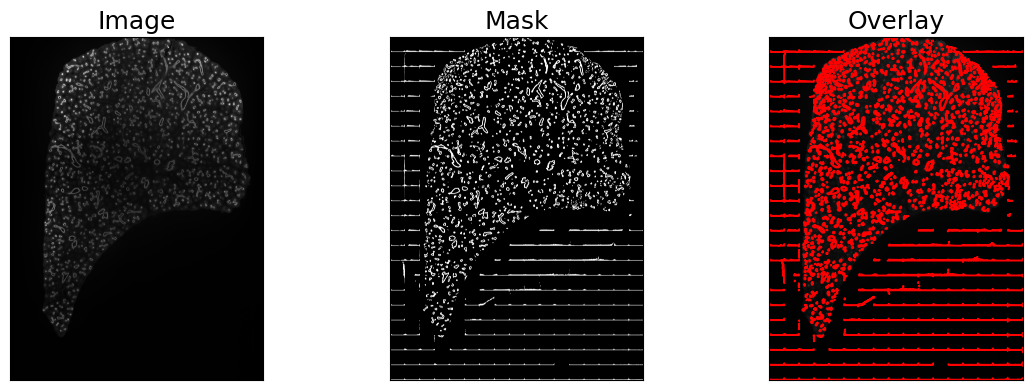

In [ ]:
from Deep_TIQ_Segmentation import example_images_plot

# Parameter allowing to pick a random image
#s_im=np.random.randint(int(len(im_lung_slice)))
s_im=150

# Show an example training image / mask pair
images = [im_lung_slice[s_im], bm_lung_slice[s_im], im_lung_slice[s_im]]

names = ['Image', 'Mask', 'Overlay']

cmaps = ['gray', 'gray', 'gray']

example_images_plot(images, names, cmaps, contour=True, contour_image=bm_lung_slice[s_im], contour_target='Overlay')

In [ ]:
trial_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Prediction/Output/Trial_0/'

input_folder = 'Mask/'

In [ ]:
def load_images_to_zstack(path, folder, file_ext, verbose_mode=True):
    ''' Load image, binary mask or weight map patches.
    ----------
    Arguments
    ----------
            path : String - Path to where the files are stored on drive
            folder : String - Folder in which the files are stored
            file_ext : String - File extension (e.g. '.tif')
    ----------
    Returns
    ----------
            zstack :  Array - 3D image stack.
    '''
    filenames = [i for i in os.listdir( path + folder ) if i.endswith(file_ext)] # Load filenames
    filenames.sort() # Sort filenames
    if verbose_mode == True:
        print('Images: ' + str(filenames))
        print( 'Number of images: ' + str( len(filenames)) )
    else:
        pass
    # Load first image to get image size
    image = img_as_ubyte( io.imread( path + folder + filenames[0] ) )
    x_dim = image.shape[0]
    y_dim = image.shape[1]
    z_dim = len(filenames)
    z_stack = np.empty((z_dim , x_dim, y_dim))
    for i in range(0, z_dim):
      z_stack[i,:,:] = img_as_ubyte(io.imread(path + folder + filenames[i]))
    #z_stack = z_stack[np.newaxis,np.newaxis,:,:,:,np.newaxis]
    #z_stack = np.moveaxis(z_stack, [2], [-5])
    return (z_stack)

In [ ]:
trial = load_images_to_zstack(trial_path, input_folder, '.tif', verbose_mode=True)

Images: ['Binary_Mask_Trial_0000.tif', 'Binary_Mask_Trial_0001.tif', 'Binary_Mask_Trial_0002.tif', 'Binary_Mask_Trial_0003.tif', 'Binary_Mask_Trial_0004.tif', 'Binary_Mask_Trial_0005.tif', 'Binary_Mask_Trial_0006.tif', 'Binary_Mask_Trial_0007.tif', 'Binary_Mask_Trial_0008.tif', 'Binary_Mask_Trial_0009.tif', 'Binary_Mask_Trial_0010.tif', 'Binary_Mask_Trial_0011.tif', 'Binary_Mask_Trial_0012.tif', 'Binary_Mask_Trial_0013.tif', 'Binary_Mask_Trial_0014.tif', 'Binary_Mask_Trial_0015.tif', 'Binary_Mask_Trial_0016.tif', 'Binary_Mask_Trial_0017.tif', 'Binary_Mask_Trial_0018.tif', 'Binary_Mask_Trial_0019.tif', 'Binary_Mask_Trial_0020.tif', 'Binary_Mask_Trial_0021.tif', 'Binary_Mask_Trial_0022.tif', 'Binary_Mask_Trial_0023.tif', 'Binary_Mask_Trial_0024.tif', 'Binary_Mask_Trial_0025.tif', 'Binary_Mask_Trial_0026.tif', 'Binary_Mask_Trial_0027.tif', 'Binary_Mask_Trial_0028.tif', 'Binary_Mask_Trial_0029.tif', 'Binary_Mask_Trial_0030.tif', 'Binary_Mask_Trial_0031.tif', 'Binary_Mask_Trial_0032.tif', '

In [ ]:
trial.shape

(1, 5, 1, 5888, 4352, 1)

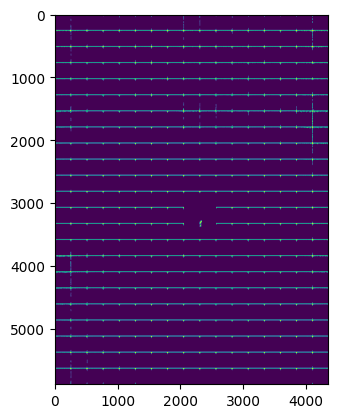

In [ ]:
plt.imshow(trial[0,4,0,:,:,0])

In [ ]:
output_path = '/content/drive/My Drive/Deep_TIQ/Human_Lung/Data_PCW14/Prediction/Output/'

In [ ]:
io.imsave(output_path + 'Binary_Mask_ZStack', trial, plugin='tifffile', check_contrast=False)

In [ ]:
mask = load_images(trial_path, input_folder, '.tif', re_size=False, new_shape=None, verbose_mode=True)

In [ ]:
z_mask = np.dstack(mask)

In [ ]:
z_mask.shape

In [ ]:
new_z_mask = z_mask[np.newaxis,np.newaxis,:,:,:,np.newaxis]

In [ ]:
new_z_mask.shape

(1, 1, 5888, 4352, 12, 1)

In [ ]:
new_z_mask_bis = np.moveaxis(new_z_mask, [4], [-5])

In [ ]:
new_z_mask_bis.shape

(1, 12, 1, 5888, 4352, 1)